# 10 - POI Enrichment

This notebook extends the cleaned Istanbul POI dataset with POI-level features that can later support:
- POI crowd estimation
- cluster/tourism-zone strength
- recommendation ranking

It uses the cleaned POI output from `03_clean_poi_data.ipynb`.

In [133]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.neighbors import BallTree

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


## Load cleaned POIs

In [134]:
pois = pd.read_csv("../data/processed/pois_istanbul_clean.csv")
pois.head()

,poi_id,name,name_en,category,lat,lon,category_clean
0,269497288,Barbaros Hayrettin Türbesi,Tomb of Hayreddin Barbarossa,historic:memorial,41.041923,29.006836,historic
1,269709058,Kanburun Bahçesi,NaN,tourism:attraction,41.042587,29.003895,attraction
2,288789401,Erbilgin Yalısı,NaN,tourism:attraction,41.118917,29.068419,attraction
3,288789412,Besteci Faik Canselen'in Evi,NaN,tourism:attraction,41.118811,29.064165,attraction
4,415157636,Yılanlı Sütun,Serpent Column,tourism:attraction,41.005665,28.975110,attraction


In [135]:
print("Shape:", pois.shape)
print("\nColumns:")
print(pois.columns.tolist())

print("\nCategory distribution:")
print(pois["category_clean"].value_counts())

Shape: (2761, 7)

Columns:
['poi_id', 'name', 'name_en', 'category', 'lat', 'lon', 'category_clean']

Category distribution:
category_clean
park          1790
historic       673
museum         157
attraction     141
Name: count, dtype: int64


## Configuration
We define Istanbul city center and spatial parameters used in feature engineering.

In [136]:
ISTANBUL_CENTER_LAT = 41.0082
ISTANBUL_CENTER_LON = 28.9784
EARTH_RADIUS_KM = 6371.0088

NEARBY_RADIUS_METERS = 500
RANDOM_STATE = 42

n_pois = len(pois)
CLUSTER_COUNT = min(max(8, int(math.sqrt(n_pois / 6))), 25)

print("POIs:", n_pois)
print("Cluster count:", CLUSTER_COUNT)

POIs: 2761
Cluster count: 21


## Helper functions

In [137]:
def minmax_scale(series):
    min_val = series.min()
    max_val = series.max()
    if min_val == max_val:
        return pd.Series(np.ones(len(series)), index=series.index)
    return (series - min_val) / (max_val - min_val)


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a))


def category_score(category):
    weights = {
        "museum": 0.85,
        "historic": 0.82,
        "attraction": 0.78,
        "park": 0.45
    }
    return weights.get(category, 0.30)


def landmark_name_score(name):
    if pd.isna(name):
        return 0.10

    name = str(name).casefold()

    keyword_weights = {
        "museum": 0.35,
        "müz": 0.35,
        "park": 0.15,
        "mosque": 0.25,
        "cami": 0.25,
        "camii": 0.25,
        "church": 0.30,
        "kilise": 0.30,
        "palace": 0.55,
        "saray": 0.55,
        "tower": 0.50,
        "kule": 0.50,
        "cistern": 0.55,
        "sarnic": 0.55,
        "basilica": 0.55,
        "bazaar": 0.40,
        "çarşı": 0.40,
        "carsi": 0.40,
        "türbe": 0.35,
        "turbe": 0.35,
        "hisar": 0.50,
        "castle": 0.50,
        "fortress": 0.50,
    }

    matches = [weight for keyword, weight in keyword_weights.items() if keyword in name]

    if not matches:
        return 0.10

    return min(1.0, max(matches) + min(0.15, 0.04 * (len(matches) - 1)))


## Distance to city center
This gives a rough centrality proxy. POIs closer to the historical/touristic center are usually more prominent.

In [138]:
pois["distance_to_center_km"] = pois.apply(
    lambda row: haversine_km(
        row["lat"],
        row["lon"],
        ISTANBUL_CENTER_LAT,
        ISTANBUL_CENTER_LON
    ),
    axis=1
)

pois[["name", "category_clean", "distance_to_center_km"]].head()

,name,category_clean,distance_to_center_km
0,Barbaros Hayrettin Türbesi,historic,4.444241
1,Kanburun Bahçesi,attraction,4.381167
2,Erbilgin Yalısı,attraction,14.440384
3,Besteci Faik Canselen'in Evi,attraction,14.247032
4,Yılanlı Sütun,attraction,0.394552


## Nearby POI density
We count how many POIs exist within a 500-meter radius.
This helps estimate local tourism concentration.

In [139]:
coords_rad = np.radians(pois[["lat", "lon"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")

radius_radians = (NEARBY_RADIUS_METERS / 1000) / EARTH_RADIUS_KM
neighbors = tree.query_radius(coords_rad, r=radius_radians)

pois["nearby_count_500m"] = [max(len(idx) - 1, 0) for idx in neighbors]

pois[["name", "nearby_count_500m"]].head()

,name,nearby_count_500m
0,Barbaros Hayrettin Türbesi,16
1,Kanburun Bahçesi,26
2,Erbilgin Yalısı,6
3,Besteci Faik Canselen'in Evi,5
4,Yılanlı Sütun,60


## Spatial clusters
We assign each POI to a spatial cluster so later we can build cluster/tourism-zone features.

In [140]:
kmeans = KMeans(
    n_clusters=CLUSTER_COUNT,
    random_state=RANDOM_STATE,
    n_init=10
)

pois["cluster_id"] = kmeans.fit_predict(pois[["lat", "lon"]])

pois[["name", "cluster_id"]].head()

,name,cluster_id
0,Barbaros Hayrettin Türbesi,10
1,Kanburun Bahçesi,12
2,Erbilgin Yalısı,15
3,Besteci Faik Canselen'in Evi,15
4,Yılanlı Sütun,12


## Derived POI feature scores
We now compute:
- category-based attractiveness
- landmark/name signal
- centrality
- density

In [141]:
pois["category_score"] = pois["category_clean"].apply(category_score)
pois["landmark_name_score"] = pois["name"].apply(landmark_name_score)

pois["centrality_score"] = 1 - minmax_scale(pois["distance_to_center_km"])
pois["density_score"] = minmax_scale(pois["nearby_count_500m"])

pois[[
    "name",
    "category_clean",
    "category_score",
    "landmark_name_score",
    "centrality_score",
    "density_score"
]].head(10)

,name,category_clean,category_score,landmark_name_score,centrality_score,density_score
0,Barbaros Hayrettin Türbesi,historic,0.82,0.35,0.946514,0.235294
1,Kanburun Bahçesi,attraction,0.78,0.10,0.947278,0.382353
2,Erbilgin Yalısı,attraction,0.78,0.10,0.825363,0.088235
3,Besteci Faik Canselen'in Evi,attraction,0.78,0.10,0.827706,0.073529
4,Yılanlı Sütun,attraction,0.78,0.10,0.995595,0.882353
5,Sabancı Üniversitesi Sakıp Sabancı Müzesi,museum,0.85,0.35,0.846958,0.029412
6,Çemberlitaş Hamamı,attraction,0.78,0.10,0.993471,0.676471
7,Millî Egemenlik Parkı,park,0.45,0.15,0.871145,0.073529
8,Siyavuşpaşa Kasrı,museum,0.85,0.10,0.870843,0.058824
9,Belgrad Kapı,historic,0.82,0.10,0.940458,0.117647


## Category flags
These will help later when we create category-sensitive crowd rules.

In [142]:
pois["is_park"] = (pois["category_clean"] == "park").astype(int)
pois["is_historic"] = (pois["category_clean"] == "historic").astype(int)
pois["is_museum"] = (pois["category_clean"] == "museum").astype(int)
pois["is_attraction"] = (pois["category_clean"] == "attraction").astype(int)

religious_keywords = [
    "mosque", "cami", "camii",
    "church", "kilise",
    "synagogue", "cathedral",
    "türbe", "turbe"
]

pois["is_religious"] = pois["name"].fillna("").str.casefold().apply(
    lambda x: int(any(keyword in x for keyword in religious_keywords))
)

pois[[
    "name",
    "is_park",
    "is_historic",
    "is_museum",
    "is_attraction",
    "is_religious"
]].head(10)

,name,is_park,is_historic,is_museum,is_attraction,is_religious
0,Barbaros Hayrettin Türbesi,0,1,0,0,1
1,Kanburun Bahçesi,0,0,0,1,0
2,Erbilgin Yalısı,0,0,0,1,0
3,Besteci Faik Canselen'in Evi,0,0,0,1,0
4,Yılanlı Sütun,0,0,0,1,0
5,Sabancı Üniversitesi Sakıp Sabancı Müzesi,0,0,1,0,0
6,Çemberlitaş Hamamı,0,0,0,1,0
7,Millî Egemenlik Parkı,1,0,0,0,0
8,Siyavuşpaşa Kasrı,0,0,1,0,0
9,Belgrad Kapı,0,1,0,0,0


## Baseline importance score
This is the first heuristic POI importance layer.

It combines:
- category type
- centrality
- local density
- landmark/name strength

In [143]:
pois["importance_score"] = (
    0.30 * pois["category_score"]
    + 0.30 * pois["centrality_score"]
    + 0.25 * pois["density_score"]
    + 0.15 * pois["landmark_name_score"]
).clip(0, 1)

pois = pois.sort_values(
    ["importance_score", "nearby_count_500m", "distance_to_center_km"],
    ascending=[False, False, True]
)

pois[[
    "name",
    "category_clean",
    "importance_score",
    "distance_to_center_km",
    "nearby_count_500m",
    "cluster_id"
]].head(20)

,name,category_clean,importance_score,distance_to_center_km,nearby_count_500m,cluster_id
507,Lausos Sarayı'nın Kalıntıları,historic,0.863004,0.248384,64,12
2160,Antiochos Sarayı'nın Kalıntıları,historic,0.859224,0.276907,63,12
2748,İbrahim Paşa Sarayı,historic,0.858915,0.361956,63,12
902,Sağlık Müzesi,museum,0.849310,0.261290,66,12
2262,Büyük Saray Mozaikleri Müzesi,museum,0.844213,0.441766,55,12
603,Sultan Ahmet Türbesi,attraction,0.835898,0.196703,68,12
410,Ayasofya Tarih ve Deneyim Müzesi,museum,0.834391,0.320059,62,12
147,Türk ve İslam Eserleri Müzesi,museum,0.834238,0.362063,62,12
60,Halı Müzesi,museum,0.827180,0.280933,60,12
1269,Keçecizâde Fuad Paşa Türbesi,historic,0.821057,0.500662,61,12


## Quick sanity checks
We inspect distributions and top-ranked POIs.

In [144]:
pois["importance_score"].describe()

count    2761.000000
mean        0.466720
std         0.107484
min         0.160102
25%         0.397306
50%         0.438437
75%         0.532514
max         0.863004
Name: importance_score, dtype: float64

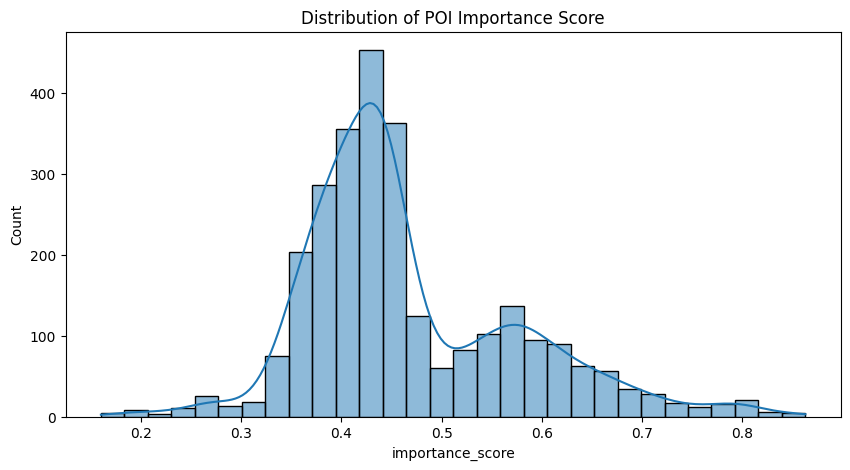

In [145]:
plt.figure(figsize=(10, 5))
sns.histplot(pois["importance_score"], bins=30, kde=True)
plt.title("Distribution of POI Importance Score")
plt.xlabel("importance_score")
plt.ylabel("Count")
plt.show()


In [146]:
top_pois = pois[[
    "poi_id",
    "name",
    "category_clean",
    "importance_score",
    "distance_to_center_km",
    "nearby_count_500m",
    "cluster_id"
]].head(30)

top_pois

,poi_id,name,category_clean,importance_score,distance_to_center_km,nearby_count_500m,cluster_id
507,13615790287,Lausos Sarayı'nın Kalıntıları,historic,0.863004,0.248384,64,12
2160,1075801479,Antiochos Sarayı'nın Kalıntıları,historic,0.859224,0.276907,63,12
2748,8120955,İbrahim Paşa Sarayı,historic,0.858915,0.361956,63,12
902,311681431,Sağlık Müzesi,museum,0.849310,0.261290,66,12
2262,1153966162,Büyük Saray Mozaikleri Müzesi,museum,0.844213,0.441766,55,12
603,103953125,Sultan Ahmet Türbesi,attraction,0.835898,0.196703,68,12
410,11867279469,Ayasofya Tarih ve Deneyim Müzesi,museum,0.834391,0.320059,62,12
147,5113500256,Türk ve İslam Eserleri Müzesi,museum,0.834238,0.362063,62,12
60,3373094254,Halı Müzesi,museum,0.827180,0.280933,60,12
1269,527580309,Keçecizâde Fuad Paşa Türbesi,historic,0.821057,0.500662,61,12


In [147]:
poi_enriched_category_means = (
    pois.groupby("category_clean")["importance_score"]
    .mean()
    .sort_values(ascending=False)
)

poi_enriched_category_means

category_clean
museum        0.638191
attraction    0.586593
historic      0.548828
park          0.411366
Name: importance_score, dtype: float64

In [148]:
pois.groupby("category_clean")["importance_score"].describe()


,count,mean,std,min,25%,50%,75%,max
category_clean,,,,,,,,
attraction,141.0,0.586593,0.102375,0.263128,0.523272,0.585852,0.640156,0.835898
historic,673.0,0.548828,0.106315,0.261000,0.475290,0.560734,0.614468,0.863004
museum,157.0,0.638191,0.087864,0.457272,0.579155,0.629777,0.688619,0.849310
park,1790.0,0.411366,0.052625,0.160102,0.383000,0.417309,0.442514,0.688313


In [149]:
for category in pois["category_clean"].dropna().unique():
    print(f"\n===== {category.upper()} =====")
    display(
        pois[pois["category_clean"] == category][[
            "name",
            "importance_score",
            "distance_to_center_km",
            "nearby_count_500m",
            "cluster_id"
        ]].head(10)
    )



===== HISTORIC =====


,name,importance_score,distance_to_center_km,nearby_count_500m,cluster_id
507,Lausos Sarayı'nın Kalıntıları,0.863004,0.248384,64,12
2160,Antiochos Sarayı'nın Kalıntıları,0.859224,0.276907,63,12
2748,İbrahim Paşa Sarayı,0.858915,0.361956,63,12
1269,Keçecizâde Fuad Paşa Türbesi,0.821057,0.500662,61,12
16,Magnaura Sarayı,0.818612,0.323760,52,12
631,Piskoposluk Sarayı,0.811736,0.192745,50,12
628,Şehzadeler Türbesi,0.807860,0.085705,57,12
610,Sultan III. Murad Türbesi,0.804154,0.093821,56,12
149,Sahabe-i Kiramdan Abdurrahman Şami Türbesi,0.803844,0.179134,56,12
1635,Sultan II. Selim Türbesi,0.800403,0.114491,55,12



===== MUSEUM =====


,name,importance_score,distance_to_center_km,nearby_count_500m,cluster_id
902,Sağlık Müzesi,0.849310,0.261290,66,12
2262,Büyük Saray Mozaikleri Müzesi,0.844213,0.441766,55,12
410,Ayasofya Tarih ve Deneyim Müzesi,0.834391,0.320059,62,12
147,Türk ve İslam Eserleri Müzesi,0.834238,0.362063,62,12
60,Halı Müzesi,0.827180,0.280933,60,12
375,Topkapi Sarayı,0.812144,0.533536,48,12
156,Marmara Üniversitesi Cumhuriyet Müzesi ve Sana...,0.804416,0.474982,54,12
38,Binbirdirek Sarnıcı,0.804169,0.340653,64,12
119,Halı Müzesi,0.801657,0.222483,53,12
2739,Aya İrini Kilisesi,0.797624,0.280210,54,12



===== ATTRACTION =====


,name,importance_score,distance_to_center_km,nearby_count_500m,cluster_id
603,Sultan Ahmet Türbesi,0.835898,0.196703,68,12
2755,Sultanahmet Camii,0.807981,0.343592,63,12
612,Alman Çeşmesi,0.791075,0.188534,66,12
510,Fulham Park Cistern,0.789254,0.681282,46,12
136,Cevri Kalfa Çeşmesi,0.783903,0.138610,64,12
137,Hacı Beşir Ağa Çeşmesi,0.776925,0.035525,62,12
544,Sultanahmet Meydanı,0.776067,0.271418,62,12
395,Yerebatan Sarnıcı,0.769588,0.031113,60,12
4,Yılanlı Sütun,0.768267,0.394552,60,12
975,Topkapı Sarayı,0.761140,0.696253,40,12



===== PARK =====


,name,importance_score,distance_to_center_km,nearby_count_500m,cluster_id
281,Mehmet Akif Ersoy Parkı,0.688313,0.252545,63,12
543,Sultan Ahmet Parkı,0.681462,0.114416,61,12
696,Binbirdirek Sarnıcı,0.672931,0.397810,61,12
620,İsa Yusuf Alptekin Parkı,0.658154,0.457829,55,12
514,Alay Meydanı,0.636325,0.354304,51,12
972,Zülüflü Baltacılar Koğuşu,0.617233,0.549534,46,12
547,Gülhane Parkı,0.617066,0.635903,44,12
2647,Dolmabahçe Sarayı Yerleşkesi,0.613888,3.855832,30,12
541,Dolmabahçe Sarayı,0.613863,3.862596,30,12
1897,Sarayburnu Parkı,0.611499,1.107159,25,12


## Cluster overview
This helps us understand the basic cluster distribution before adding Wikipedia.

In [150]:
pois["cluster_id"].value_counts().sort_index()

cluster_id
0      91
1     194
2     107
3     223
4     148
5     162
6      17
7      26
8      23
9      55
10    220
11    129
12    457
13     78
14    214
15     95
16     82
17    276
18    119
19     37
20      8
Name: count, dtype: int64

In [151]:
cluster_summary = pois.groupby("cluster_id").agg(
    poi_count=("poi_id", "count"),
    avg_importance=("importance_score", "mean"),
    avg_density=("nearby_count_500m", "mean"),
    avg_distance_to_center=("distance_to_center_km", "mean")
).sort_values("avg_importance", ascending=False)

cluster_summary.head(10)

,poi_count,avg_importance,avg_density,avg_distance_to_center
cluster_id,,,,
12,457,0.628044,23.614880,2.574923
1,194,0.511451,5.350515,5.824818
17,276,0.506712,6.818841,6.207030
10,220,0.484190,4.772727,8.690883
3,223,0.445474,4.076233,11.186344
14,214,0.442589,4.168224,10.833710
15,95,0.433671,1.684211,19.938976
5,162,0.432574,2.092593,13.759608
16,82,0.423095,2.000000,16.557085


## Final enriched dataset
We keep only the columns needed for the next POI steps.

In [152]:
poi_enriched = pois[[
    "poi_id",
    "name",
    "name_en",
    "category",
    "category_clean",
    "lat",
    "lon",
    "distance_to_center_km",
    "nearby_count_500m",
    "cluster_id",
    "category_score",
    "landmark_name_score",
    "centrality_score",
    "density_score",
    "importance_score",
    "is_park",
    "is_historic",
    "is_museum",
    "is_attraction",
    "is_religious"
]].copy()

poi_enriched.head()

,poi_id,name,name_en,category,category_clean,lat,lon,distance_to_center_km,nearby_count_500m,cluster_id,category_score,landmark_name_score,centrality_score,density_score,importance_score,is_park,is_historic,is_museum,is_attraction,is_religious
507,13615790287,Lausos Sarayı'nın Kalıntıları,NaN,historic:archaeological_site,historic,41.007586,28.975554,0.248384,64,12,0.82,0.55,0.997367,0.941176,0.863004,0,1,0,0,0
2160,1075801479,Antiochos Sarayı'nın Kalıntıları,NaN,historic:archaeological_site,historic,41.007289,28.975329,0.276907,63,12,0.82,0.55,0.997021,0.926471,0.859224,0,1,0,0,0
2748,8120955,İbrahim Paşa Sarayı,Ibrahim Pasha Palace,historic:castle,historic,41.006397,28.974808,0.361956,63,12,0.82,0.55,0.995990,0.926471,0.858915,0,1,0,0,0
902,311681431,Sağlık Müzesi,NaN,tourism:museum,museum,41.008314,28.975290,0.261290,66,12,0.85,0.35,0.997210,0.970588,0.849310,0,0,1,0,0
2262,1153966162,Büyük Saray Mozaikleri Müzesi,Great Palace Mosaic Museum,tourism:museum,museum,41.004295,28.977433,0.441766,55,12,0.85,0.59,0.995023,0.808824,0.844213,0,0,1,0,0


In [153]:
poi_enriched.to_csv("../data/processed/poi_enriched.csv", index=False)
print("Saved: ../data/processed/poi_enriched.csv")
print("Shape:", poi_enriched.shape)

Saved: ../data/processed/poi_enriched.csv
Shape: (2761, 20)


## Conclusion

This notebook created a baseline POI enrichment layer from existing OSM-derived POIs.

In [154]:
keywords = [
    "Ayasofya", "Topkap", "Yerebatan", "Sultanahmet",
    "Galata", "Dolmabah", "Basilica", "Kız", "Maiden"
]

for kw in keywords:
    print(f"\n--- {kw} ---")
    display(
        poi_enriched[
            poi_enriched["name"].str.contains(kw, case=False, na=False)
        ][["name", "category_clean", "importance_score", "distance_to_center_km", "nearby_count_500m"]]
        .head(10)
    )



--- Ayasofya ---


,name,category_clean,importance_score,distance_to_center_km,nearby_count_500m
410,Ayasofya Tarih ve Deneyim Müzesi,museum,0.834391,0.320059,62
2727,Ayasofya-i Kebir Câmi-i Şerifi,museum,0.768184,0.126230,54
611,Ayasofya-i Kebir Câmi-i Şerifi,attraction,0.747139,0.138448,54



--- Topkap ---


,name,category_clean,importance_score,distance_to_center_km,nearby_count_500m
375,Topkapi Sarayı,museum,0.812144,0.533536,48
975,Topkapı Sarayı,attraction,0.761140,0.696253,40
128,Hamidiye Kültür Ve Eğitim Vakfı Topkapı Nusret,museum,0.590761,4.432708,10
787,Topkapı Şehir Parkı,park,0.472744,4.938876,9



--- Yerebatan ---


...

,name,category_clean,importance_score,distance_to_center_km,nearby_count_500m



--- Kız ---


,name,category_clean,importance_score,distance_to_center_km,nearby_count_500m
772,Kızlarağası Dairesi,historic,0.663742,4.130493,32
50,Kıztaşı,historic,0.614550,2.492646,17
2735,Kız Kulesi,attraction,0.607057,2.587930,2
599,Kız Kulesi,attraction,0.607042,2.591855,2
1170,Bakırköy Sakızağacı Parkı,park,0.437604,8.536478,3
1420,Kızılcık bahçesi,park,0.425828,9.712528,3
1327,Kızılay Trafo Parkı,park,0.398500,21.313804,5
1109,Hatice hatun kız kuran kursu,park,0.368678,22.397301,0



--- Maiden ---


,name,category_clean,importance_score,distance_to_center_km,nearby_count_500m


Is the heuristic ranking obviously important landmarks high enough? Validation:

In [155]:
anchor_keywords = {
    "Hagia Sophia": ["Ayasofya"],
    "Blue Mosque": ["Sultanahmet Camii", "Sultan Ahmet Camii"],
    "Topkapi Palace": ["Topkapi", "Topkapı"],
    "Basilica Cistern": ["Yerebatan", "Binbirdirek", "Basilica"],
    "Dolmabahce Palace": ["Dolmabahçe", "Dolmabahce"],
    "Galata Tower": ["Galata"],
    "Grand Bazaar": ["Kapalıçarşı", "Kapalicarsi", "Grand Bazaar"],
    "Suleymaniye Mosque": ["Süleymaniye", "Suleymaniye"],
    "Spice Bazaar": ["Mısır Çarşısı", "Misir Carsisi", "Spice Bazaar"],
    "Maiden's Tower": ["Kız Kulesi", "Kiz Kulesi", "Maiden"],
}

In [156]:
ranking_df = pois.reset_index(drop=True).copy()
ranking_df["rank"] = ranking_df.index + 1

anchor_results = []

for anchor_name, keywords in anchor_keywords.items():
    pattern = "|".join(keywords)
    
    matches = ranking_df[
        ranking_df["name"].str.contains(pattern, case=False, na=False, regex=True)
    ][[
        "rank",
        "name",
        "category_clean",
        "importance_score",
        "distance_to_center_km",
        "nearby_count_500m"
    ]].copy()
    
    if matches.empty:
        anchor_results.append({
            "anchor": anchor_name,
            "matched": False,
            "best_rank": None,
            "best_name": None,
            "importance_score": None
        })
    else:
        best_match = matches.sort_values("rank").iloc[0]
        anchor_results.append({
            "anchor": anchor_name,
            "matched": True,
            "best_rank": int(best_match["rank"]),
            "best_name": best_match["name"],
            "importance_score": float(best_match["importance_score"])
        })

anchor_results_df = pd.DataFrame(anchor_results)
anchor_results_df


,anchor,matched,best_rank,best_name,importance_score
0,Hagia Sophia,True,7.0,Ayasofya Tarih ve Deneyim Müzesi,0.834391
1,Blue Mosque,True,14.0,Sultanahmet Camii,0.807981
2,Topkapi Palace,True,12.0,Topkapi Sarayı,0.812144
3,Basilica Cistern,True,17.0,Binbirdirek Sarnıcı,0.804169
4,Dolmabahce Palace,True,59.0,Dolmabahçe Sarayı Harem Bölümü,0.744336
5,Galata Tower,True,103.0,Galatasaray Müzesi,0.699559
6,Grand Bazaar,False,NaN,NaN,NaN
7,Suleymaniye Mosque,True,411.0,Süleymaniye İmareti,0.588177
8,Spice Bazaar,False,NaN,NaN,NaN
9,Maiden's Tower,True,338.0,Kız Kulesi,0.607057


In [157]:
def anchor_status(rank):
    if pd.isna(rank):
        return "Missing"
    if rank <= 20:
        return "Excellent"
    if rank <= 50:
        return "Good"
    if rank <= 100:
        return "Acceptable"
    return "Too low"

anchor_results_df["status"] = anchor_results_df["best_rank"].apply(anchor_status)
anchor_results_df.sort_values(["best_rank"], na_position="last")


,anchor,matched,best_rank,best_name,importance_score,status
0,Hagia Sophia,True,7.0,Ayasofya Tarih ve Deneyim Müzesi,0.834391,Excellent
2,Topkapi Palace,True,12.0,Topkapi Sarayı,0.812144,Excellent
1,Blue Mosque,True,14.0,Sultanahmet Camii,0.807981,Excellent
3,Basilica Cistern,True,17.0,Binbirdirek Sarnıcı,0.804169,Excellent
4,Dolmabahce Palace,True,59.0,Dolmabahçe Sarayı Harem Bölümü,0.744336,Acceptable
5,Galata Tower,True,103.0,Galatasaray Müzesi,0.699559,Too low
9,Maiden's Tower,True,338.0,Kız Kulesi,0.607057,Too low
7,Suleymaniye Mosque,True,411.0,Süleymaniye İmareti,0.588177,Too low
6,Grand Bazaar,False,NaN,NaN,NaN,Missing
8,Spice Bazaar,False,NaN,NaN,NaN,Missing


In [158]:
status_counts = anchor_results_df["status"].value_counts()
status_counts


status
Excellent     4
Too low       3
Missing       2
Acceptable    1
Name: count, dtype: int64